In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

## Завантаження набору даних

In [5]:
happiness_df = pd.read_csv('world-happiness-report-2021.csv')

# Перегляд перших рядків
happiness_df.head()


,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798


## Попередня перевірка набору даних

In [6]:
# Перевірка на пропущені значення
happiness_df[['Country name','Logged GDP per capita','Healthy life expectancy']].info()
happiness_df[['Logged GDP per capita','Healthy life expectancy']].isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country name             149 non-null    object 
 1   Logged GDP per capita    149 non-null    float64
 2   Healthy life expectancy  149 non-null    float64
dtypes: float64(2), object(1)
memory usage: 3.6+ KB


Logged GDP per capita      0
Healthy life expectancy    0
dtype: int64

In [7]:
# Вибираємо ознаки для кластеризації
X = happiness_df[['Logged GDP per capita','Healthy life expectancy']].values

## Масштабуємо дані

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Elbow Method
Використовується для отримання оптимальної кількості кластерів k.

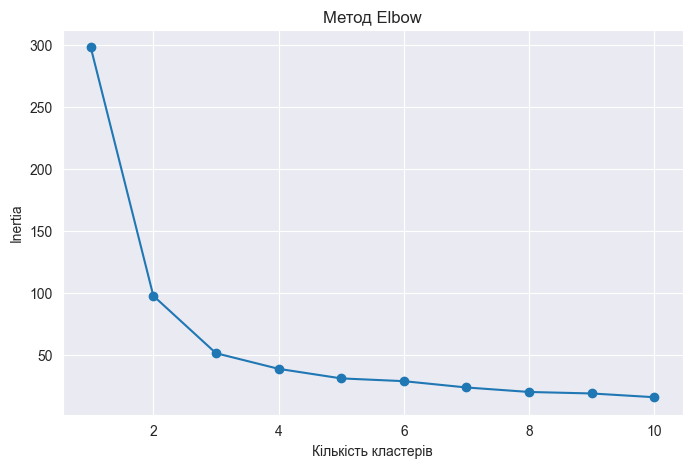

In [6]:
inertia_list = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0)
    kmeans.fit(X_scaled)
    inertia_list.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia_list, marker='o')
plt.title('Метод Elbow')
plt.xlabel('Кількість кластерів')
plt.ylabel('Inertia')
plt.show()


## Побудова моделі

In [7]:
kmeans_model = KMeans(n_clusters=4, init='k-means++', random_state=0)
y_kmeans = kmeans_model.fit_predict(X)

# Додаємо колонку кластерів
happiness_df['Cluster'] = y_kmeans

# Центроїди кластерів
print("Центроїди кластерів:")
print(kmeans_model.cluster_centers_)


Центроїди кластерів:
[[ 8.62486207 59.73858621]
 [10.73014706 73.11991176]
 [ 7.75331818 53.36345455]
 [ 9.685625   67.05367188]]


## Графічне представлення

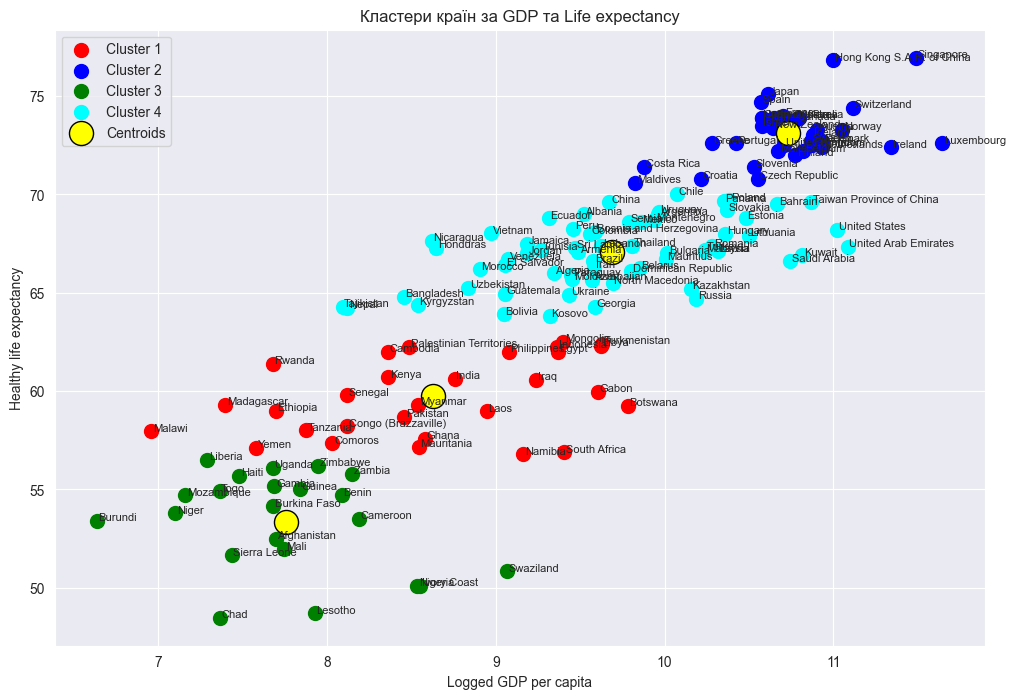

In [11]:
plt.figure(figsize=(12,8))
colors = ['red','blue','green','cyan']

for i in range(4):
    plt.scatter(X[y_kmeans==i,0], X[y_kmeans==i,1],s=100, c=colors[i], label=f'Cluster {i+1}')

# Центроїди
plt.scatter(kmeans_model.cluster_centers_[:,0],kmeans_model.cluster_centers_[:,1],s=300, c='yellow', label='Centroids', edgecolors='black')

# Додаємо підписи країн
for i, country in enumerate(happiness_df['Country name']):
    plt.text(X[i,0]+0.01, X[i,1]+0.01, country, fontsize=8)

plt.title('Кластери країн за GDP та Life expectancy')
plt.xlabel('Logged GDP per capita')
plt.ylabel('Healthy life expectancy')
plt.legend()
plt.show()


In [35]:
# Середні значення ознак у кожному кластері
cluster_summary = happiness_df.groupby('Cluster')[['Logged GDP per capita','Healthy life expectancy']].mean()
cluster_summary

,Logged GDP per capita,Healthy life expectancy
Cluster,,
0,8.624862,59.738586
1,10.730147,73.119912
2,7.753318,53.363455
3,9.685625,67.053672
